## 1. Modul Praktikum Pengolahan Bahasa Alami
### 1.1. Processing and Understanding Text in Indonesian Language using spaCy

#### Notebook ini merupakan materi untuk modul praktikum mata kuliah Pengolahan Bahasa Alami
di Program Studi Informatika, Fakultas Teknologi Industri, Universitas Atma Jaya Yogyakarta
Kebutuhan yang harus dipenuhi terkait modul praktikum ini adalah: 1. Python 2. spaCy 3. Model
spaCy untuk Bahasa Indonesia (nusantara)

In [23]:
import spacy
import pandas as pd

!pip install "id_nusantara-1.1.tar.gz"
!python -m pip install jupyterlab ipywidgets
# for JupyterLab < 3:
!python -m jupyter labextension install @jupyter-widgets/jupyterlab-manager

## TODO: Load Model spacy dengan id nusantara
nlp = spacy.load("id_nusantara")


Defaulting to user installation because normal site-packages is not writeable
Processing ./id_nusantara-1.1.tar.gz
  Preparing metadata (setup.py) ... done
  Created wheel for id_nusantara: filename=id_nusantara-1.1-py3-none-any.whl size=8244119 sha256=a2882e82ca4634af9227d1741e8624fb2e122204f7c8d1518f0c66a405a0d6d1
  Stored in directory: /home/jupyter-230712298/.cache/pip/wheels/9c/b8/e7/3d14f23e0751a7afc2af5d319b9ec7644f339f992540ed470a
Successfully built id_nusantara
  Attempting uninstall: id_nusantara
    Found existing installation: id_nusantara 1.1
    Uninstalling id_nusantara-1.1:
      Successfully uninstalled id_nusantara-1.1
Defaulting to user installation because normal site-packages is not writeable
(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encourag

/opt/tljh/user/lib/python3.12/site-packages/spacy/util.py:922: UserWarning: [W095] Model 'id_nusantara' (1.1) was trained with spaCy v3.7.5 and may not be 100% compatible with the current version (3.8.7). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [38]:
df_uploaded = pd.read_csv("./data_230712298.csv")

### Tokenisasi

#### Tokenisasi Kalimat

In [100]:
## Langkah ini adalah untuk melakukan tokenisasi kalimat dari data teks Bahasa Indonesia yang telah
## didefinisikan dan akan digunakan dalam proses pemrosesan teks.
processed_data = []
for _, row in df_uploaded.iterrows():
    review = row['Review']
    doc = nlp(review)

    print(f"Review: {review}")
    print("===================================")

    for sentence_id, sent in enumerate(doc.sents):
        print("Kalimat:")
        print([token.text for token in sent])
        print("------------------")
    print("\n\n")

Review: Toko fashion ini punya koleksi baju yang sangat lengkap dan rapi.
Kalimat:
['Toko', 'fashion', 'ini', 'punya', 'koleksi', 'baju', 'yang', 'sangat', 'lengkap', 'dan', 'rapi', '.']
------------------



Review: Harga pakaian di sini cukup terjangkau untuk kualitas yang diberikan.
Kalimat:
['Harga', 'pakaian', 'di', 'sini', 'cukup', 'terjangkau', 'untuk', 'kualitas', 'yang', 'diberikan', '.']
------------------



Review: Pelayan toko sangat ramah dan membantu memilih ukuran yang pas.
Kalimat:
['Pelayan', 'toko', 'sangat', 'ramah', 'dan', 'membantu', 'memilih', 'ukuran', 'yang', 'pas', '.']
------------------



Review: Model bajunya kekinian dan cocok untuk anak muda maupun dewasa.
Kalimat:
['Model', 'bajunya', 'kekinian', 'dan', 'cocok', 'untuk', 'anak', 'muda', 'maupun', 'dewasa', '.']
------------------



Review: Kualitas bahan pakaiannya bagus, nyaman dipakai seharian penuh.
Kalimat:
['Kualitas', 'bahan', 'pakaiannya', 'bagus', ',', 'nyaman', 'dipakai', 'seharian', 'penuh', 

In [104]:
sentences = [sent for sent in doc.sents]

In [105]:
sample_sent = sentences[0]

In [106]:
print(f"Kalimat Pertama: {sample_sent.text}")
print("------------------")

Kalimat Pertama: Secara keseluruhan pengalaman belanja di sini sangat memuaskan dan nyaman.
------------------


#### Tokenisasi Kata

In [107]:
for token in sentences[0]:
    ## TODO: Bagaimana cara print hasil tokenasi kata dari kalimat pertama?
    print(token.text)

Secara
keseluruhan
pengalaman
belanja
di
sini
sangat
memuaskan
dan
nyaman
.


### Lematisasi

In [108]:
## Langkah ini adalah untuk melakukan lematisasi kata dari data kalimat teks Bahasa Indonesia yang
## telah didefinisikan dan akan digunakan dalam proses pemrosesan teks

for token in sentences[0]:
    
    ## TODO: Bagaimana cara print hasil lematisasi kata dari kalimat pertama?
    
    print(token.lemma_)

secara
keseluruhan
pengalaman
belanja
di
sini
sangat
puas
dan
nyaman
.


In [109]:
for token in sentences[0]:
    ## TODO: Bagaimana cara print hasil normalisasi kata dari kalimat pertama?
    print(token.lemma_.lower())

secara
keseluruhan
pengalaman
belanja
di
sini
sangat
puas
dan
nyaman
.


### Tagging

#### Langkah 1: POS Tagging (Coarse-grained part-of-speech from the UniversalPOS tag set.)
#### untuk arti dari setiap TAG dapat dilihat di  https://universaldependencies.org/treebanks/id_gsd/index.html

In [110]:
## Langkah ini adalah untuk melakukan POS tagging kata dari data kalimat teks Bahasa Indonesia
## yang telah didefinisikan dan akan digunakan dalam proses pemrosesan teks.

for token in sentences[0]:
    ## TODO: Bagaimana cara print hasil POS taggiing (Coarse-grained) kata dari kalimat pertama?
    print(token.text, token.pos_)
    

Secara ADP
keseluruhan PRON
pengalaman NOUN
belanja NOUN
di ADP
sini PRON
sangat ADV
memuaskan VERB
dan CCONJ
nyaman ADJ
. PUNCT


#### Langkah 2: POS Tagging (Fine-grained part-of-speech)

In [111]:
for token in sentences[0]:
    
    ## TODO: Bagaimana cara print hasil POS tagging (Fine-grained) kata dari kalimat pertama?
    
    print(token.text, token.tag_)

Secara R--
keseluruhan B--
pengalaman NSD
belanja NSD
di R--
sini NSD
sangat D--
memuaskan VSA
dan H--
nyaman ASP
. Z--


### Parsing

#### Dependency Parsing

In [112]:
## Langkah ini adalah untuk melakukan identifikasi relasi ketergantungan sintaksis kata dari data
## kalimat teks Bahasa Indonesia yang telah didefinisikan dan akan digunakan dalam proses pemrosesan teks

try:
    sentences
except NameError:
    raise RuntimeError(
        "Variabel 'sentences' tidak ditemukan. Jalankan sel tokenisasi (doc.sents) terlebih dahulu.")

import pandas as pd
from IPython.display import display, HTML
import ipywidgets as widgets


def show_deps(idx):
    sent = sentences[idx]
    
    ## TODO: Bagaimana cara membuat list untuk token, dep, dan head dari kalimat yang dipilih?
    tokens = []
    deps = []
    heads = []

    for token in sent:
        tokens.append(token.text)
        deps.append(token.dep_)
        heads.append(token.head.text)
    
    df = pd.DataFrame({'Token': tokens, 'Dep': deps, 'Head': heads})
    ## beri display untuk head adalah token yang menjadi kepala dari token tersebut
    legend = """
    <div style="border:1px solid #ddd;padding:8px;border-radius:6px;background:#f9f9f9;margin-bottom:8px;">
      <b>Legend:</b>
      <ul style="margin:4px 0 0 18px;padding:0;">
        <li><b>Token</b>: kata/token dalam kalimat.</li>
        <li><b>Dep</b>: label dependensi sintaksis (relasi antara token dan kepala).</li>
        <li><b>Head</b>: token yang menjadi pengontrol sintaksis dari token saat ini — yaitu kata yang token tersebut bergantung padanya. Untuk token root, head biasanya menunjuk pada token itu sendiri.</li>
      </ul>
    </div>
    """
    display(HTML(f"<b>Kalimat {idx} (Asli):</b> {sent.text}"))
    display(HTML(legend))
    display(df)


slider = widgets.IntSlider(min=0, max=len(
    sentences)-1, step=1, description='Kalimat:')
out = widgets.interactive_output(show_deps, {'idx': slider})
display(widgets.VBox([slider, out]))

In [113]:
from spacy import displacy
displacy.render(sentences[0], style="dep")

In [114]:
sentence_spans = list(doc.sents)
displacy.render(sentence_spans, style="dep")

### Case Identification

In [115]:
## Langkah ini adalah untuk melakukan identifikasi case kata dari data kalimat teks Bahasa Indonesia
## yang telah didefinisikan dan akan digunakan dalam proses pemrosesan teks
for token_id, token in enumerate(sent):
    
    ## TODO: Bagaimana cara Mengeluarkan hasil identifikasi kata?
    if token.is_upper:
        case_identification = f"{token.text} is in UPPERCASE"
    elif token.is_lower:
        case_identification = f"{token.text} is in lowercase"
    elif token.is_title:
        case_identification = f"{token.text} is in Title Case"
    else:
        case_identification = f"{token.text} has a mixed case"

### Morphology 

#### Morphology Analysis

In [125]:
## Langkah ini adalah untuk melakukan identifikasi morpologi kata dari data kalimat teks Bahasa
## Indonesia yang telah didefinisikan dan akan digunakan dalam proses pemrosesan teks.

try:
    sentences
except NameError:
    raise RuntimeError(
        "Variabel 'sentences' tidak ditemukan. Jalankan sel tokenisasi (doc.sents) terlebih dahulu.")

import pandas as pd
from IPython.display import display, HTML
import ipywidgets as widgets


def show_morph(idx):
    sent = sentences[idx]
   
    
    ## TODO: Bagaimana mengeluarkan token dan hasil morfologi kata dari kalimat yang dipilih?
    
    tokens = []
    morphs = []

    for token in sent:
        tokens.append(token.text)
        morphs.append(str(token.morph)) 
    
    df = pd.DataFrame({'Token': tokens, 'Morph': morphs})
    display(HTML(f"<b>Kalimat {idx} (Asli):</b> {sent.text}"))
    display(df)


slider = widgets.IntSlider(min=0, max=len(
    sentences)-1, step=1, description='Kalimat:')
out = widgets.interactive_output(show_morph, {'idx': slider})
display(widgets.VBox([slider, out]))

### Sastrawi 

In [126]:
!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory



## TODO: Bagaimana cara inisialisasi stemmer untuk Bahasa Indonesia menggunakan library Sastrawi?
factory = StemmerFactory()
stemmer = factory.create_stemmer()




## stemmer adalah untuk melakukan proses stemming atau pengembalian kata ke bentuk dasarnya dari data kalimat teks Bahasa Indonesia yang telah didefinisikan dan akan digunakan dalam proses pemrosesan teks.
## penggunaan stemmer untuk kalimat pertama 

## perbandingan sebelum stemming dan sesudah stemming
try:
    stemmer
except NameError:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

import pandas as pd
from IPython.display import display, HTML
import ipywidgets as widgets

# daftar kalimat
sent_texts = [sent.text for sent in sentences]

def show_sentence(idx):
    sent = sentences[idx]
    tokens = [t.text for t in sent]
    ## TODO: bagaimana cara melakukan stemming untuk setiap token dalam kalimat yang dipilih?
    stems = [stemmer.stem(token) for token in tokens]
    
    df = pd.DataFrame({'Token': tokens, 'Stem': stems})
    display(HTML(f"<b>Kalimat {idx} (Asli):</b> {sent.text}"))
    display(HTML(f"<b>Kalimat {idx} (Stemmed - full):</b> {stemmer.stem(sent.text)}"))
    display(df)

slider = widgets.IntSlider(min=0, max=len(sentences)-1, step=1, description='Kalimat:')
out = widgets.interactive_output(show_sentence, {'idx': slider})
display(widgets.VBox([slider, out]))
    

Defaulting to user installation because normal site-packages is not writeable


# Menampilkan tabel Tugas Modul 1

In [127]:
for sentence_id, sent in enumerate(doc.sents):
    
    morphology = str(token.morph) if token.morph else ''
    
    processed_data.append({
        'review_id': review_id,
        'review': review,
        'sentence_id': sentence_id,
        'sentence': sent.text,
        'token_id': token_id,
        'token': token.text,
        'lemma': token.lemma_,
        'pos': token.pos_,
        'dep': token.dep_,
        'case': case_identification,
        'morph': morphology
    })
            
processed_df = pd.DataFrame(processed_data)
print(len(processed_data))
processed_df.head(50)

443


,review_id,review,sentence_id,sentence,token_id,token,lemma,pos,dep,case,morph
0,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko,toko,PROPN,nsubj,Toko is in Title Case,
1,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,1,fashion,fashion,PROPN,flat:name,fashion is in lowercase,
2,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,2,ini,ini,DET,det,ini is in lowercase,PronType=Dem
3,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,3,punya,punya,VERB,ROOT,punya is in lowercase,Mood=Ind|Voice=Act
4,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,4,koleksi,koleksi,NOUN,obj,koleksi is in lowercase,Number=Sing
5,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,5,baju,baju,NOUN,compound,baju is in lowercase,Number=Sing
6,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,6,yang,yang,PRON,nsubj,yang is in lowercase,PronType=Rel
7,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,7,sangat,sangat,ADV,advmod,sangat is in lowercase,
8,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,8,lengkap,lengkap,ADJ,acl:relcl,lengkap is in lowercase,
9,0,Toko fashion ini punya koleksi baju yang sanga...,0,Toko fashion ini punya koleksi baju yang sanga...,9,dan,dan,CCONJ,cc,dan is in lowercase,


## TUGAS

1. Carilah minimal 30 hingga 50 review google maps berbahasa indonesia dengan minimal 5 kata per review (Review tempat kuliner, sandang/fashion, dan kerajinan). 
2. Proseslah data tersebut dengan menggunakan modul spaCy untuk mendapatkan hasil tokenisasi, lemmatisasi, tagging, parsing, case identification, dan morphology.
3. Setelah itu tampilkan dalam dataset hasil dari proses tersebut dalam bentuk tabel dengan kolom-kolom sebagai berikut: 1. Review, 2. Kalimat, 3. Kata 4. Lemma, 5. POS Tag, 6. Dependency, 7. Case Identification, dan 8. Morphology.

contoh dari hasil yang diharapkan seperti berikut:

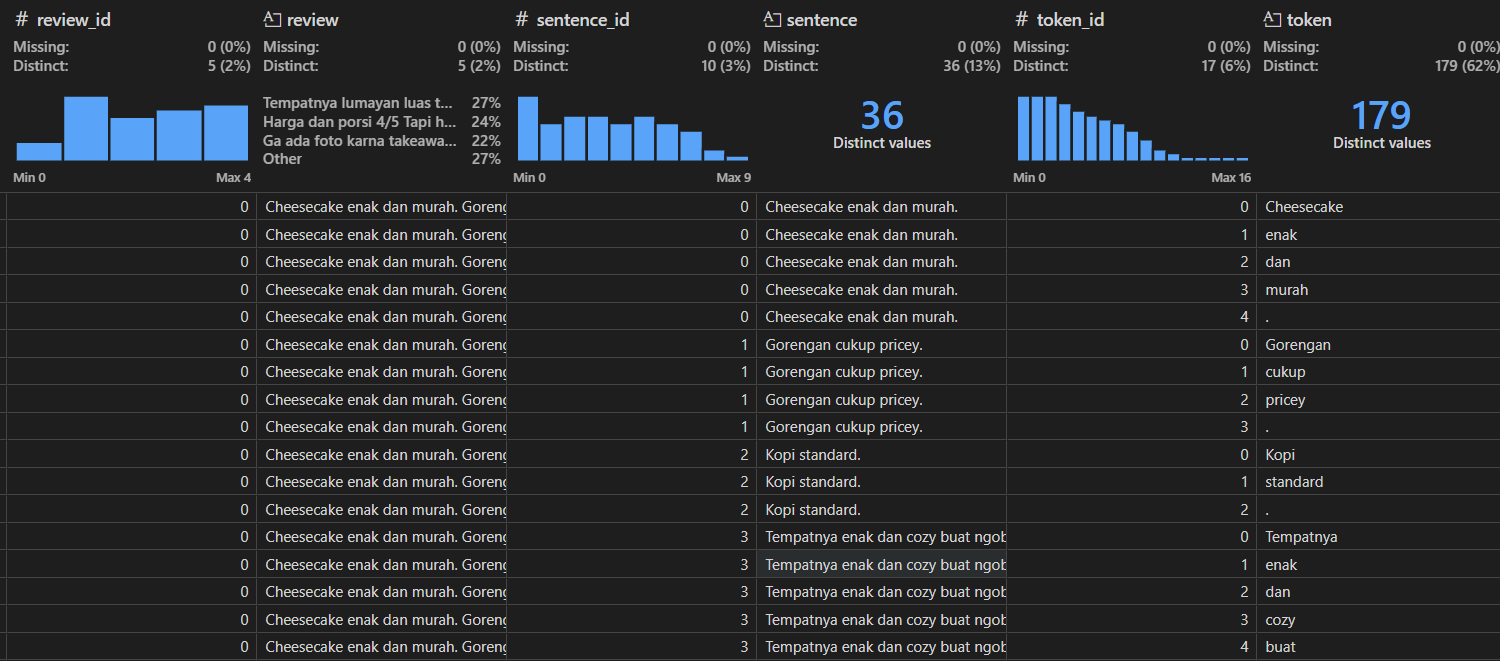

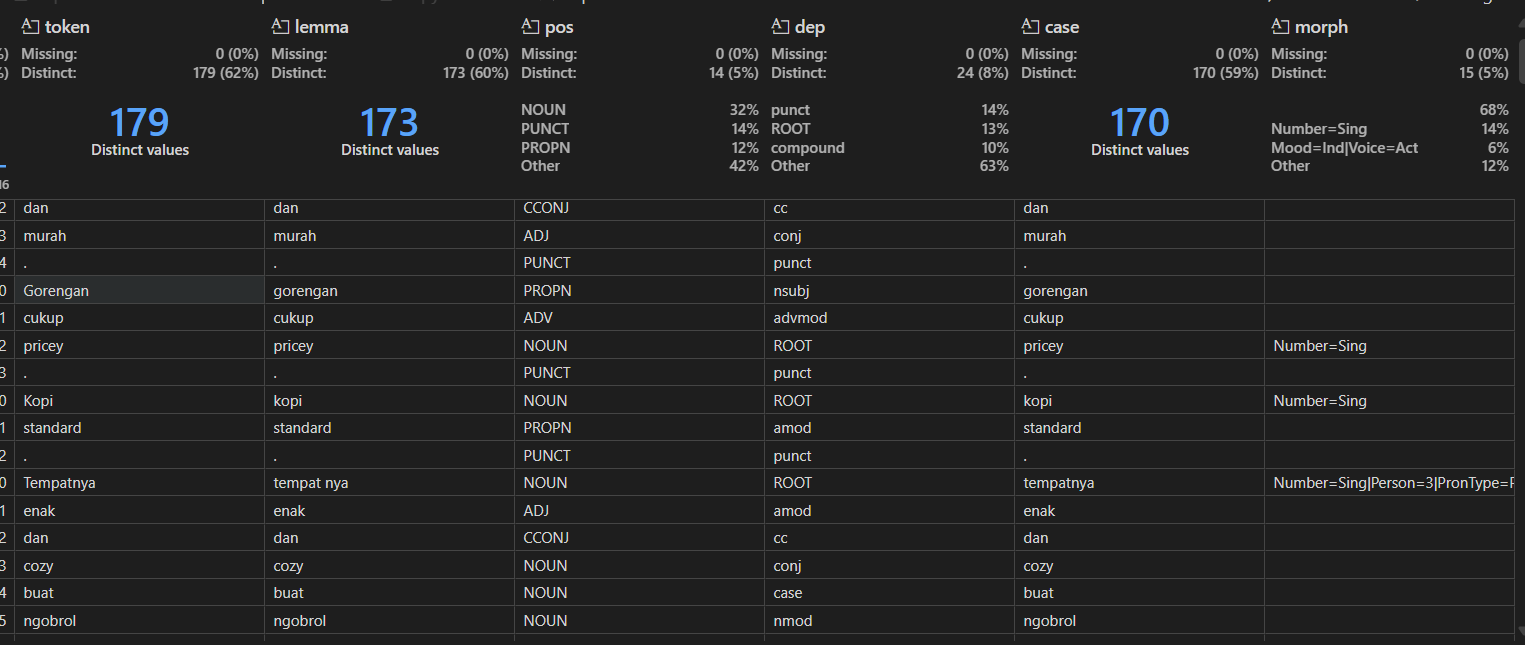

catatan : 
1. hasil dari morphology bisa saja kosong karena model nusantara belum memiliki fitur morphologi yang lengkap
2. Hasil untuk POS Tag dan Dependency dapat salah karena model nusantara belum memiliki fitur tagging dan parsing yang lengkap, namun tetap tampilkan hasilnya apa adanya
